In [5]:

import os

print(os.listdir('/content'))

['.config', 'drive', 'bank-full.csv', 'sample_data']


In [6]:

import pandas as pd

# Load the larger banking dataset
df = pd.read_csv('/content/bank-full.csv', sep=';')

# Check the dataset size
print("Total rows and columns:", df.shape)

# Count customers who subscribed and did not subscribe
print("\nSubscription results:")
print(df["y"].value_counts())

# Calculate the subscription rate
subscription_rate = (df["y"] == "yes").mean() * 100
print(f"\nSubscription rate: {subscription_rate:.2f}%")

Total rows and columns: (45211, 17)

Subscription results:
y
no     39922
yes     5289
Name: count, dtype: int64

Subscription rate: 11.70%


In [7]:

# Check data types and non-empty values
print("DATASET INFORMATION")
df.info()

# Check for missing values
print("\nMISSING VALUES")
print(df.isnull().sum().sum())

# Check for duplicate rows
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

MISSING VALUES
0

DUPLICATE ROWS
0


In [8]:

# Subscription rate by contact type
contact_rate = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print("SUBSCRIPTION RATE BY CONTACT TYPE (%)")
print(contact_rate.round(2))

# Subscription rate by job category
job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print("\nSUBSCRIPTION RATE BY JOB CATEGORY (%)")
print(job_rate.round(2))

SUBSCRIPTION RATE BY CONTACT TYPE (%)
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64

SUBSCRIPTION RATE BY JOB CATEGORY (%)
job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: y, dtype: float64


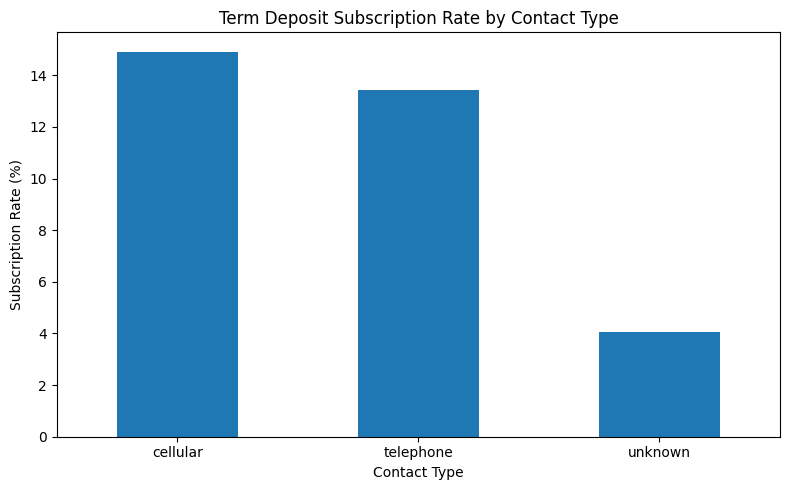

In [9]:

import matplotlib.pyplot as plt

# Create a bar chart
contact_rate.plot(kind="bar", figsize=(8, 5))

# Add chart labels and title
plt.title("Term Deposit Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

# Display the chart
plt.show()

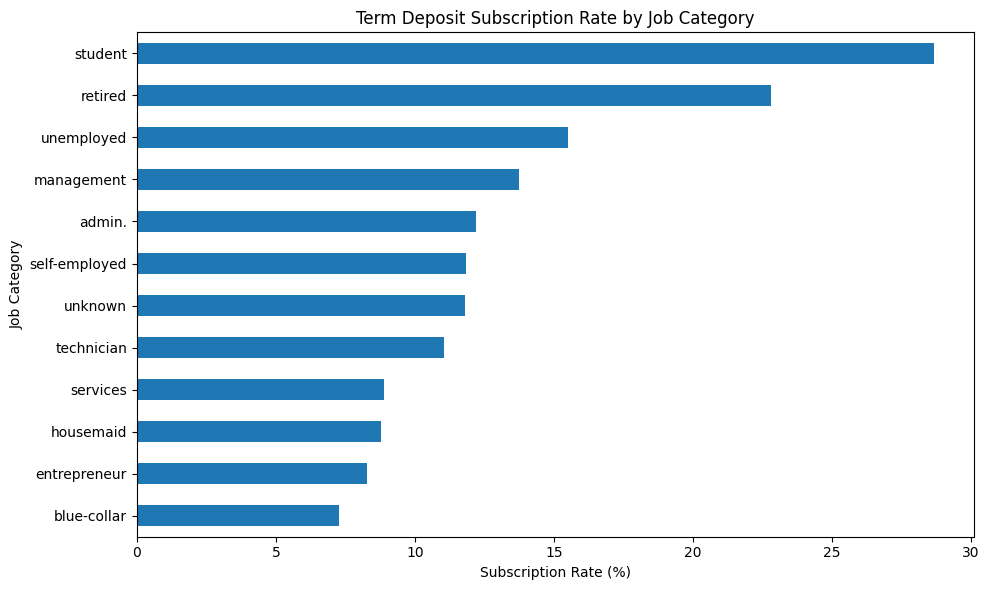

In [10]:

import matplotlib.pyplot as plt

# Sort job categories from lowest to highest
job_rate_sorted = job_rate.sort_values()

# Create a horizontal bar chart
job_rate_sorted.plot(kind="barh", figsize=(10, 6))

# Add chart labels and title
plt.title("Term Deposit Subscription Rate by Job Category")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Category")
plt.tight_layout()

# Display the chart
plt.show()

## Key Business Insights

### 1. Contact Channel Performance

Customers contacted through cellular had the highest observed term deposit subscription rate at 14.92%, followed by telephone at 13.42%. Customers with an unknown contact type had a lower rate of 4.07%. The campaign team could investigate whether improving contact information and evaluating outreach channels may help improve engagement.

### 2. Subscription Rate by Job Category

Students recorded the highest subscription rate at 28.68%, followed by retired customers at 22.79%. Blue-collar workers had the lowest observed rate at 7.27%. These differences suggest that subscription patterns vary across job categories and may warrant further investigation.

### 3. Business Recommendation

The bank could investigate the characteristics and campaign history of customers in higher-subscription-rate groups. Before allocating more resources to any group or channel, it should also consider the number of customers in each group, campaign costs, and whether the observed differences persist in future campaigns.

### 4. Data Quality

The dataset contains 45,211 records and 17 columns. Initial checks found no missing values and no exact duplicate rows. The subscription rate is 11.70%, with 5,289 customers subscribing and 39,922 not subscribing.


In [11]:

# Save the dataset as a CSV file
df.to_csv('/content/bank_campaign_clean.csv', index=False)

print("Dataset exported successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset exported successfully!
Rows: 45211
Columns: 17


In [12]:

from google.colab import files

files.download('/content/bank_campaign_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:

import sqlite3

# Create a database file
conn = sqlite3.connect('/content/bank_campaign.db')

# Store our dataset in a SQL table
df.to_sql(
    'bank_campaign',
    conn,
    if_exists='replace',
    index=False
)

print("SQL database created successfully!")

# Check the number of records
result = conn.execute(
    "SELECT COUNT(*) FROM bank_campaign"
).fetchone()

print("Total records in SQL:", result[0])

SQL database created successfully!
Total records in SQL: 45211


In [14]:

query = """
SELECT
    contact,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subscribed,
    ROUND(
        100.0 * SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END)
        / COUNT(*), 2
    ) AS subscription_rate_pct
FROM bank_campaign
GROUP BY contact
ORDER BY subscription_rate_pct DESC;
"""

contact_results = pd.read_sql_query(query, conn)

contact_results

,contact,total_customers,subscribed,subscription_rate_pct
0,cellular,29285,4369,14.92
1,telephone,2906,390,13.42
2,unknown,13020,530,4.07


In [15]:

job_query = """
SELECT
    job,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS subscribed,
    ROUND(
        100.0 * SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END)
        / COUNT(*), 2
    ) AS subscription_rate_pct
FROM bank_campaign
GROUP BY job
ORDER BY subscription_rate_pct DESC;
"""

job_results = pd.read_sql_query(job_query, conn)

job_results

,job,total_customers,subscribed,subscription_rate_pct
0,student,938,269,28.68
1,retired,2264,516,22.79
2,unemployed,1303,202,15.50
3,management,9458,1301,13.76
4,admin.,5171,631,12.20
5,self-employed,1579,187,11.84
6,unknown,288,34,11.81
7,technician,7597,840,11.06
8,services,4154,369,8.88
9,housemaid,1240,109,8.79


In [17]:

# Export SQL analysis results for Power BI
contact_results.to_csv(
    '/content/contact_analysis.csv',
    index=False
)

job_results.to_csv(
    '/content/job_analysis.csv',
    index=False
)

print("SQL analysis results exported successfully!")
print("Files created:")
print("- contact_analysis.csv")
print("- job_analysis.csv")

SQL analysis results exported successfully!
Files created:
- contact_analysis.csv
- job_analysis.csv


In [18]:

from google.colab import files

files.download('/content/contact_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>